In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pgmpy.factors.discrete import TabularCPD
from skpro.regression.gam import GAMRegressor as GAM

np.random.seed(42)

# =========================================================
# 1. Generate Training Data for the Pipeline
# =========================================================
print("=== 1. Generating Data & Fitting Models ===")
n_train = 200

# [Data for CPD1] diff -> grade
# If diff=0 (Easy), higher chance of grade=1. If diff=1 (Hard), lower chance.
diff_train = np.random.choice([0, 1], size=n_train)
grade_train = np.where(
    diff_train == 0, 
    np.random.choice([0, 1], p=[0.2, 0.8], size=n_train), 
    np.random.choice([0, 1], p=[0.7, 0.3], size=n_train)
)
train_data_cpd1 = pd.DataFrame({'diff': diff_train, 'grade': grade_train})

# [Data for CPD2] grade + study_time -> score
# Score depends non-linearly on study_time and linearly on grade
study_time_train = np.random.uniform(0, 10, size=n_train)
score_train = 40 + (20 * grade_train) + (15 * np.sin(study_time_train / 1.5)) + np.random.normal(0, 3, n_train)

train_data_cpd2_X = pd.DataFrame({'grade': grade_train, 'study_time': study_time_train})
train_data_cpd2_y = pd.Series(score_train)


=== 1. Generating Data & Fitting Models ===


In [11]:
# =========================================================
# 2. Initialize and Fit Models (CPD1 & CPD2)
# =========================================================
# Fit CPD1 (Discrete: TabularCPD)
cpd1 = TabularCPD(variable='grade', variable_card=2, 
                  values=np.ones((2, 2)) / 2, evidence=['diff'], evidence_card=[2])
cpd1.fit(X=train_data_cpd1)
print("\n[CPD1 - TabularCPD] Fitted probability table:")
print(cpd1)

# Fit CPD2 (Continuous: GAM)
cpd2 = GAM()
cpd2.fit(train_data_cpd2_X, train_data_cpd2_y)
print("[CPD2 - GAM] Model fitting complete.")



[CPD1 - TabularCPD] Fitted probability table:
+----------+---------+---------+
| diff     | diff(0) | diff(1) |
+----------+---------+---------+
| grade(0) | 0.16    | 0.71    |
+----------+---------+---------+
| grade(1) | 0.84    | 0.29    |
+----------+---------+---------+
[CPD2 - GAM] Model fitting complete.


In [12]:
# =========================================================
# 3. Simulate Data Flow: CPD1 -> CPD2
# =========================================================
print("\n=== 2. Executing Pipeline: CPD1 -> CPD2 ===")

# Test scenario: 3 students with different difficulties and study times
test_inputs = pd.DataFrame({
    'diff': [0, 1, 0],            # Easy, Hard, Easy
    'study_time': [2.0, 5.0, 8.0] # 2 hours, 5 hours, 8 hours
})

# Step A: CPD1 predicts categorical probability of 'grade' based on 'diff'
pred_grade_dist = cpd1.predict_proba(test_inputs[['diff']])

# Step B: Sample concrete 'grade' values from CPD1's predicted distribution (to pass to CPD2)
# Sample 1 value per student and flatten to a 1D array
sampled_grades = pred_grade_dist.sample(n_samples=1, random_state=42).flatten()

print("Sampled Grades (Output of CPD1 -> Input of CPD2):")
for i, g in enumerate(sampled_grades):
    print(f"  Student {i}: diff={test_inputs['diff'].iloc[i]} -> Sampled grade={g}")

# Step C: Combine sampled 'grade' with 'study_time' to create input for CPD2
# Fix: Convert sampled_grades from object type to int type to prevent skpro TypeErrors
cpd2_test_inputs = pd.DataFrame({
    'grade': sampled_grades.astype(int),  # <--- Explicitly cast to integer
    'study_time': test_inputs['study_time']
})

# Step D: CPD2 predicts continuous 'score' distribution based on CPD1's output
pred_score_dist = cpd2.predict_proba(cpd2_test_inputs)

print("\nPredicted Score Distributions (Normal Dist from CPD2):")
print("  Means:\n", pred_score_dist.mean().values)
print("  Variances:\n", pred_score_dist.var().values)



=== 2. Executing Pipeline: CPD1 -> CPD2 ===
Sampled Grades (Output of CPD1 -> Input of CPD2):
  Student 0: diff=0 -> Sampled grade=1
  Student 1: diff=1 -> Sampled grade=0
  Student 2: diff=0 -> Sampled grade=1

Predicted Score Distributions (Normal Dist from CPD2):
  Means:
 [[74.73484271]
 [37.5261808 ]
 [47.74764023]]
  Variances:
 [[2.95248341]
 [2.95248341]
 [2.95248341]]



=== 3. Plotting Results ===


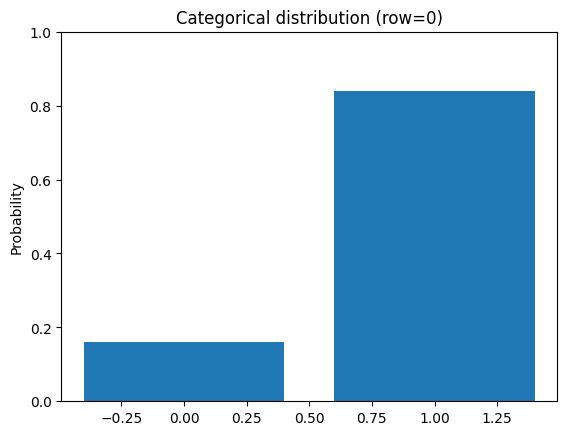

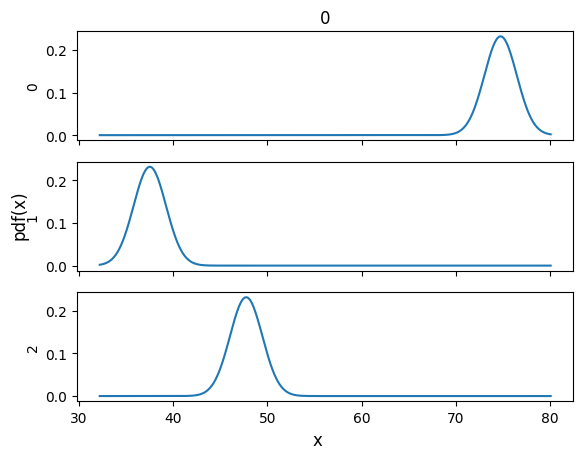

In [13]:
# =========================================================
# 4. Visualization (plot distribution from CPD2)
# =========================================================
print("\n=== 3. Plotting Results ===")

pred_grade_dist.plot()
pred_score_dist.plot()

plt.show()
